In [8]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2 as cv
import os

In [9]:
def extrair_e_visualizar_planos_de_bits(caminho_imagem_entrada, diretorio_saida="planos_de_bits"):
    """
    Carrega uma imagem, a converte para escala de cinza, e extrai e visualiza
    cada um dos 8 planos de bits separadamente.

    Args:
        caminho_imagem_entrada (str): O caminho para a imagem a ser processada.
        diretorio_saida (str): O diretório onde as imagens dos planos de bits serão salvas.
    """
    try:
        print(caminho_imagem_entrada)
        array_imagem = cv.imread(caminho_imagem_entrada, cv.IMREAD_GRAYSCALE)

        altura, largura = array_imagem.shape
        print(f"Imagem de entrada lida: {largura}x{altura} pixels.")

        # Iterar por cada plano de bit (de 0 a 7)
        for i in range(8):
            # Cria um array para o plano de bit atual, inicialmente todo preto
            plano_bit_array = np.zeros((altura, largura), dtype=np.uint8)

            # Para cada pixel na imagem original
            for y in range(altura):
                for x in range(largura):
                    valor_pixel = array_imagem[y, x] # 00001011 1011 & 10011011
                    # Verifica se o i-ésimo bit (da direita para a esquerda) está SETADO (é '1')
                    # Usamos uma máscara de bit (1 << i) para isolar o bit desejado.
                    # Se o bit estiver setado, o pixel na imagem do plano de bit será branco (255).
                    if (valor_pixel >> i) & 1: # Equivalente a: (valor_pixel & (1 << i)) != 0
                        plano_bit_array[y, x] = 255
                    # Senão, ele permanece 0 (preto)

            nome_arquivo_saida = os.path.join(diretorio_saida, f"plano_bit_{i}.png")
            cv.imwrite(nome_arquivo_saida, plano_bit_array)
            print(f"Plano de Bit {i} salvo em: '{nome_arquivo_saida}'")
            
        print("\nProcessamento concluído. Verifique o diretório '", diretorio_saida, "' para as imagens.")
        
    except Exception as e:
        print(f"Ocorreu um erro inesperado: {e}")

In [10]:
path_image = "./../../../CH03_Original_Images/Fig0314(a)(100-dollars).tif"
extrair_e_visualizar_planos_de_bits(path_image)

./../../../CH03_Original_Images/Fig0314(a)(100-dollars).tif
Imagem de entrada lida: 1192x500 pixels.
Plano de Bit 0 salvo em: 'planos_de_bits/plano_bit_0.png'
Plano de Bit 1 salvo em: 'planos_de_bits/plano_bit_1.png'
Plano de Bit 2 salvo em: 'planos_de_bits/plano_bit_2.png'
Plano de Bit 3 salvo em: 'planos_de_bits/plano_bit_3.png'
Plano de Bit 4 salvo em: 'planos_de_bits/plano_bit_4.png'
Plano de Bit 5 salvo em: 'planos_de_bits/plano_bit_5.png'
Plano de Bit 6 salvo em: 'planos_de_bits/plano_bit_6.png'
Plano de Bit 7 salvo em: 'planos_de_bits/plano_bit_7.png'

Processamento concluído. Verifique o diretório ' planos_de_bits ' para as imagens.


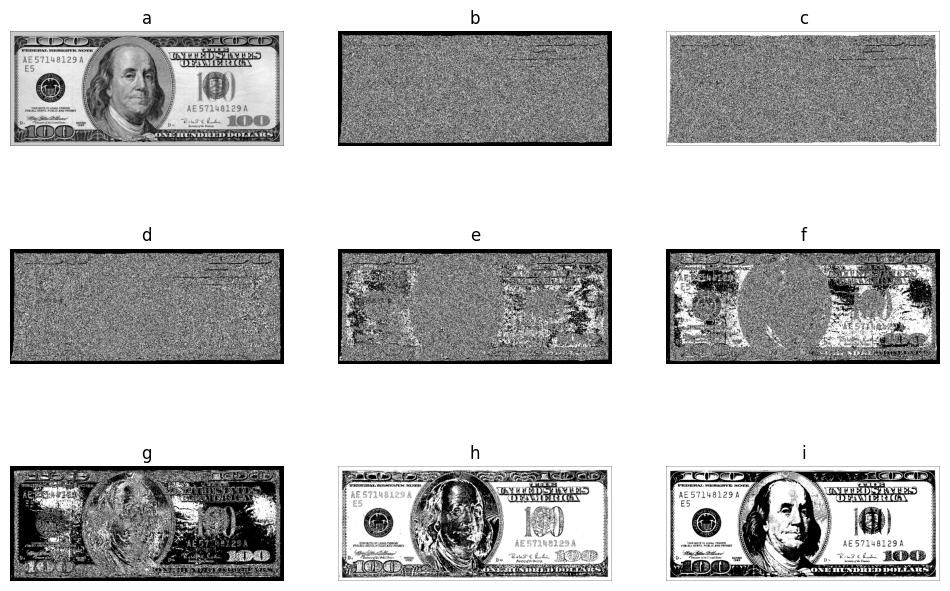

In [ ]:
# Visualizando o painel

legends = ["a", "b", "c", "d", "e", "f", "g", "h", "i"]

fig, axes = plt.subplots(3, 3, figsize=(12,8))
axes = axes.flatten()

img_original = Image.open(path_image)

images_listed = os.listdir("planos_de_bits")
images_listed.sort()

num_images_to_plot = min(len(images_listed), 9)

for i in range(num_images_to_plot):
    ax = axes[i]
    filepath = os.path.join("planos_de_bits", images_listed[i])
    img = Image.open(filepath)
    ax.imshow(img, cmap="gray")
    ax.set_title(legends[i])
    ax.axis("off")


plt.show()